summarization, open source

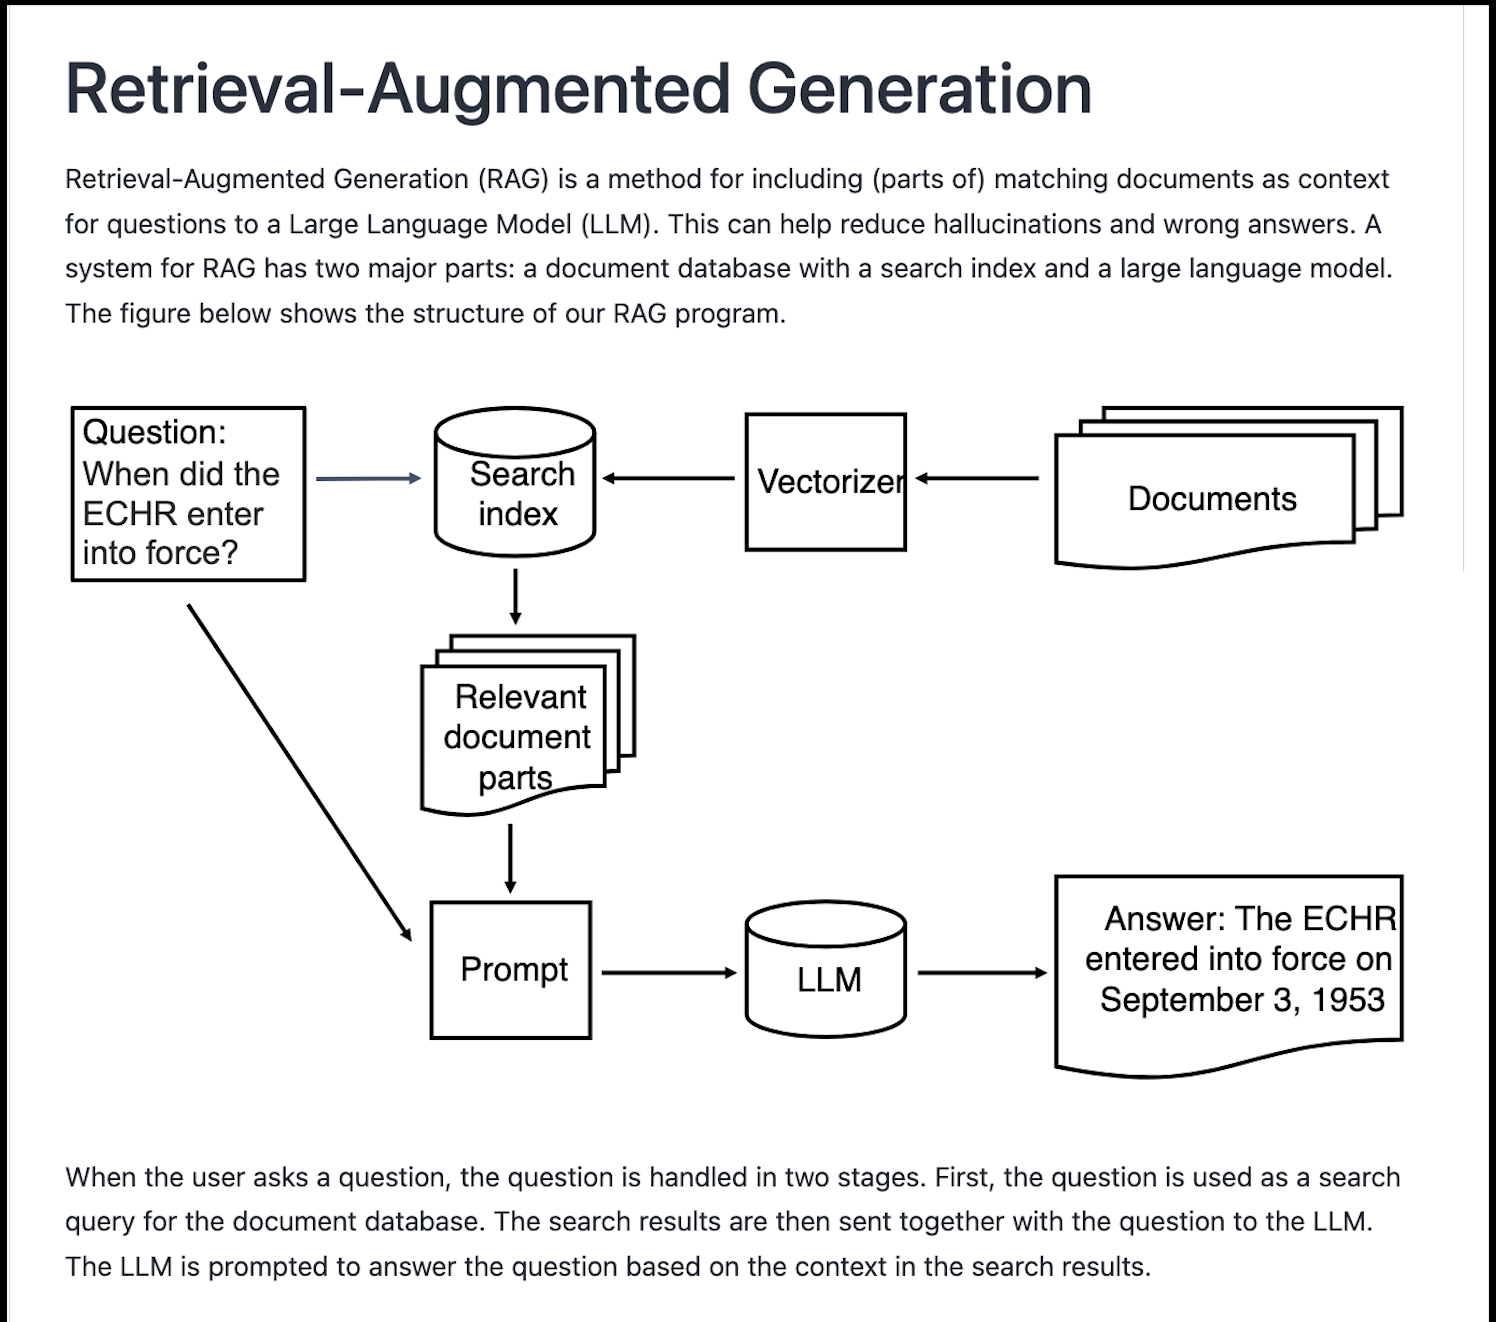

Our project is the result of team work. We have two sets of
documentation pages. Thanks to our [team member for illustrating the
process](https://uio-library.github.io/LLM-course/4_RAG.html) .

Recommended location of the document folder: Replace the section for
username with your own.

Code view 1:

    #document_folder = '/fp/projects01/ec443/documents'
    document_folder = '/fp/homes01/u01/{ec-username}/documents'

The location of the models repeated.

Code view 2:

    %env HF_HOME=/fp/projects01/ec443/huggingface/cache/

code view 3:

    from langchain_huggingface.llms import HuggingFacePipeline

    llm = HuggingFacePipeline.from_model_id(
        model_id='mistralai/Mistral-7B-Instruct-v0.3',
        task='text-generation',
        device=0,
        pipeline_kwargs={
            'max_new_tokens': 500,
            'do_sample': True,
            'temperature': 0.3,
            'num_beams': 4
        }
    )

First, we are going to use the language model without connecting it to
the documents. The output will be what the model knows from before, on
the subject we ask.

code view 4:

    # Use with models from Meta
    #llm.pipeline.tokenizer.pad_token_id = llm.pipeline.tokenizer.eos_token_id

    query = 'What are the major contributions of the Trivandrum Observatory?'
    output = llm.invoke(query)

The answer will be printed in markdown.

code view 5:

    from IPython.display import Markdown
    display(Markdown(output))

# The Vectorizer

Text must be vectorized before it can be processed. Our HuggingFace
pipeline will do that automatically for the large language model. But we
must make a vectorizer for the search index for our documents database.
We use a vectorizer called a word embedding model from HuggingFace.
Again, the HuggingFace library will automatically download the model.
You can read more on the [Embedding model
here](https://huggingface.co/BAAI/bge-m3) . The developer writes this in
the readme file: "BGE M3 is an embedding model supporting dense
retrieval, lexical matching and multi-vector interaction".

code view 6:

    from langchain_community.embeddings import HuggingFaceBgeEmbeddings

    huggingface_embeddings = HuggingFaceBgeEmbeddings(
        model_name='BAAI/bge-m3',
        model_kwargs = {'device': 'cuda:0'},
        #or: model_kwargs={'device':'cpu'},
        encode_kwargs={'normalize_embeddings': True}
    )

# Loading the documents

code view 7:

    from langchain_community.document_loaders import DirectoryLoader

    loader = DirectoryLoader(document_folder)
    documents = loader.load()

Counting the documents.

code view 8:

    print(f'Number of documents:', len(documents))
    print('Maximum document length: ', max([len(doc.page_content) for doc in documents]))

We can examine one of the documents

code view 9:

    print(documents[0])

# Splitting the documents

code view 9:

    from langchain.text_splitter import RecursiveCharacterTextSplitter

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = 700, #  Could be more, for larger models like mistralai/Ministral-8B-Instruct-2410
        chunk_overlap  = 200,
    )
    documents = text_splitter.split_documents(documents)

We can check if the maximum document length has changed:

code view 10:

    print(f'Number of documents:', len(documents))
    print('Maximum document length: ', max([len(doc.page_content) for doc in documents]))

# The Document Index

code view 11:

    from langchain_community.vectorstores import FAISS
    vectorstore = FAISS.from_documents(documents, huggingface_embeddings)

code view 12:

    relevant_documents = vectorstore.similarity_search(query)
    print(f'Number of documents found: {len(relevant_documents)}')

code view 13:

    print(relevant_documents[0].page_content)

For our RAG application we need to access the search engine through an
interface called a retriever:

code view 14:

    retriever = vectorstore.as_retriever(search_kwargs={'k': 3})

# Making a prompt

code view 15:

    from langchain.prompts import PromptTemplate

    prompt_template = '''You are an assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question.
    Context: {context}

    Question: {input}

    Answer:
    '''

    prompt = PromptTemplate(template=prompt_template,
                            input_variables=['context', 'input'])

# Making the "Chatbot"

code view 16:

    from langchain.chains import create_retrieval_chain
    from langchain.chains.combine_documents import create_stuff_documents_chain

    combine_documents_chain = create_stuff_documents_chain(llm, prompt)
    rag_chain = create_retrieval_chain(retriever, combine_documents_chain)

# Asking the "Chatbot"

code view 17:

    result = rag_chain.invoke({'input': query})

code view 18:

    print(result['answer'])

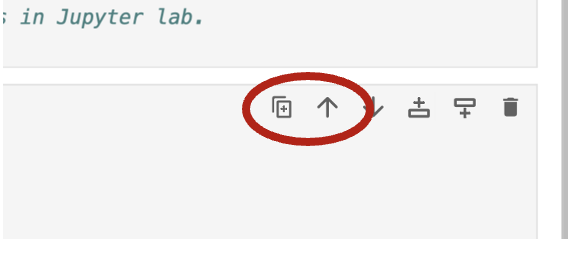

Note

Task 10.2: Use copy cell in jupyter lab in order to get e a copy of the
summarization cell. Change some of the parameters, and see if the output
changes.